# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 2: ON + OFF Edges | Michael Zhou | Georgia Tech ECE**

This notebook extends Experiment 1 to test whether the representational geometry finding generalizes across stimulus polarity — using both ON and OFF moving edges as stimuli (24 conditions: 12 directions × 2 polarities). A fidelity signal that holds across polarities would strengthen the claim that representational geometry reflects a general property of connectome structure, not a feature of the ON pathway alone.

**Key question:** Does the direction-sensitive representational geometry observed for ON edges also emerge for OFF edges, and does the combined ON+OFF geometry remain specific to connectome-constrained networks?

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [ ]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 23.16 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.6 MB/s et

## Experiment

**Stimuli:** 24 moving edge conditions — 12 directions at 30° increments (0°
  through 330°) × 2 polarities (ON and OFF edges)

**Networks:**
- *Connectome-constrained (CC):* 50 models from the pretrained Flyvis ensemble
  (indices `000–049` within `flow/0000`, pre-sorted by task error), trained to
  perform optic flow estimation on naturalistic video with connectome-fixed
  architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with sign-preserving weight
  shuffles. Three strategies were evaluated:
  1. **Full Shiu-style shuffle (canonical):** all 734 free parameters shuffled;
     stability-constrained sampling rejects configurations with non-finite
     activations and resamples up to 100 times per model. This is the canonical
     baseline, mirroring the Experiment 1 canonical fidelity run.
  2. Synapse-only shuffle: only the 604 unitary synapse scaling factors
     (`edges_syn_strength`) shuffled, preserving trained time constants and
     resting potentials — per Lappalainen et al. (2024) Methods, time constants
     are clamped during training to prevent instability. Used for n=50
     instability documentation runs.
  3. Matched-instability baseline: full Shiu-style shuffle without stability
     filtering; non-finite activations clamped to ±1e3 in RDM construction.
     Retained for comparison against the stability-constrained result.

**Acceptance rate (strategy 1):** 50/50 models accepted; mean 7.9 ± 8.5 attempts
  (range: 1–42); 6/50 first-try — confirming that dynamically stable configurations
  occupy a small fraction of full Shiu weight space across the full ensemble.

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in
  response to each stimulus condition

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`);
`torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry across all
  24 conditions
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's $\tau_A$ RDM correlation — preferred for RDM data with ties
  (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Stimulus-label permutation test — nonparametric inference on RDM correlations
  (Nili et al. 2014, 10,000 permutations)
- Within-ensemble consistency — measures stability of CC representational
  geometry across trained solutions
- Polarity generalization — whether direction-sensitive geometry observed for ON
  edges in Experiment 1 extends to OFF edges and the combined ON+OFF space
- Within-polarity direction structure — CC and random OFF-OFF and ON-ON
  submatrices plotted together in a 2×2 grid with row-level shared colormaps
  (CC row and Random row scaled independently), making the circular direction
  gradient visible in the CC row while communicating the magnitude difference
  between CC (~0.012) and random (~0.040) via different colorbar ranges;
  circular structure formally tested via permutation test against a circular
  distance reference; ON/OFF asymmetry tested by Fisher z-transform (analytical
  cross-check) and model-level bootstrap (primary inference, 10,000 samples,
  50 CC models resampled with replacement)

In [ ]:
"""
Experiment 2: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON + OFF Edges

This script extends Experiment 1 (ON edges only) to test whether connectome-constrained
networks (Lappalainen et al. 2024) produce geometrically distinct population codes
compared to randomly initialized networks when stimulated with both ON and OFF moving
edges. A meaningful fidelity signal across both polarities would strengthen the claim
that representational geometry is a general property of the connectome constraint,
not specific to the ON pathway.

Experiment:
- Stimuli: 24 moving edge conditions (12 directions × 2 polarities: ON and OFF)
- Networks: pretrained connectome-constrained ensemble (all 50) vs random baseline
- Population vectors: peak central-cell response per cell type (65-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Canonical runs:
    # Comparison result (n=10, full Shiu-style shuffle, stability-constrained)
    results = run_experiment(n_models=10, randomization_strategy="full_shiu")

    # Canonical fidelity result (n=50, full Shiu-style shuffle, stability-constrained)
    results = run_experiment(n_models=50, randomization_strategy="full_shiu")

    # Instability documentation (n=50, synapse-only shuffle)
    results = run_experiment(n_models=50, randomization_strategy="synapse_only")

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau, norm
from google.colab import files

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]  # 12 directions (30° increments)
INTENSITIES = [0, 1]                                                # ON (1) and OFF (0) edges

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=INTENSITIES,         # include both ON and OFF
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])
    pop_vec = np.clip(pop_vec, -1e6, 1e6)  # guard against near-overflow values
    # that pass finiteness check but cause scipy cosine distance to overflow

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Clamp any residual inf/nan to large finite values as a defensive measure.
    # Under stability-constrained sampling, non-finite activations should not
    # reach this point; clamping is retained as a safeguard.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    # Add small epsilon before cosine distance computation to prevent NaN from
    # zero-norm population vectors. A stable network can still produce an
    # all-zero response vector for a given stimulus (e.g. if the network is
    # unresponsive to that direction or polarity), which makes cosine distance
    # undefined.
    if metric == "cosine":
        norms = np.linalg.norm(pop_matrix, axis=1, keepdims=True)
        zero_norm_rows = (norms < 1e-10).flatten()
        if np.any(zero_norm_rows):
            print(f"    WARNING: {zero_norm_rows.sum()} zero-norm population "
                  f"vectors detected — adding epsilon")
        pop_matrix = pop_matrix + 1e-10

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation and Kendall's tau_A between upper
    triangles of two RDMs. Kendall's tau_A is preferred for RDM data with
    ties (Nili et al. 2014); Spearman retained for comparison.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 5b. HELPER: PERMUTATION TEST ─────────────────────────────────────────────

def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """
    Stimulus-label randomization test for RDM correlation (Nili et al. 2014).

    Permutes rows and columns of rdm2 simultaneously to preserve RDM symmetry,
    building a null distribution of RDM correlations under the hypothesis that
    the two RDMs are unrelated. The one-sided p-value is the proportion of
    permuted correlations >= the observed correlation.

    This is the recommended fixed-effects inference procedure from Nili et al.
    (2014) when a single RDM estimate is available (rather than multiple subjects).

    Args:
        rdm1: numpy array of shape (n_stimuli, n_stimuli) — reference RDM
        rdm2: numpy array of shape (n_stimuli, n_stimuli) — candidate RDM
              (stimulus labels of this RDM are permuted)
        n_permutations: number of permutations (default: 10000)
        seed: random seed for reproducibility

    Returns:
        obs_r:    observed Spearman correlation
        p_r:      permutation p-value for Spearman
        obs_tau:  observed Kendall tau_A
        p_tau:    permutation p-value for Kendall tau_A
        null_r:   null distribution of Spearman correlations
        null_tau: null distribution of Kendall tau_A values
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)

    # Observed correlations
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])

    # Null distribution via stimulus-label permutation
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)

    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])

    # One-sided p-value: proportion of null >= observed
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)

    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network, strategy="full_shiu"):
    """
    Randomize network weights using the specified strategy, preserving E/I
    sign structure throughout.

    Args:
        network: Flyvis network instance
        strategy: "full_shiu"    — shuffle all 734 free parameters (resting
                                   potentials, time constants, synapse scaling
                                   factors). Used for canonical fidelity runs (n=10
                                   and n=50, stability-constrained).
                                   Stability-constrained: r = 0.783 (n=10), r = 0.846 (n=50).
                                   Matched-instability:   r = 0.862 (n=10).
                  "synapse_only" — shuffle only the 604 unitary synapse scaling
                                   factors (edges_syn_strength), preserving
                                   trained time constants and resting potentials.
                                   Per Lappalainen et al. (2024) Methods, time
                                   constants are clamped during training to prevent
                                   instability. Used for n=50 instability runs.

    Returns:
        network with randomized weights
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                if strategy == "synapse_only":
                    if "time_const" in name or "nodes_bias" in name:
                        continue
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network

def randomize_weights_stable(network_view, strategy="full_shiu",
                              max_attempts=50, stimulus=None, dt=None):
    """
    Repeatedly randomize network weights until a stable configuration is found.

    On each attempt, reloads the network from checkpoint (ensuring a clean
    trained starting point), randomizes weights via randomize_weights(), and
    runs a single forward pass to check for finite outputs. The first
    configuration that produces all-finite activations is returned.

    This is the stability-constrained alternative to the matched-instability
    baseline (which accepts unstable configurations and clamps them in
    build_rdm). Using this function ensures every random baseline RDM entry
    reflects a genuine population response rather than a numerical artifact.

    Args:
        network_view: flyvis NetworkView instance — used to reload the network
                      from checkpoint on each attempt via init_network()
        strategy:     weight randomization strategy passed to randomize_weights()
                      ("full_shiu" or "synapse_only")
        max_attempts: maximum number of randomization attempts before giving up
                      (default: 50). If all attempts fail, returns (None, max_attempts).
        stimulus:     torch.Tensor of shape (n_frames, 721) or (n_frames, 1, 721)
                      used for the stability check forward pass. Should be a
                      representative stimulus — typically the first stimulus in
                      the experimental set.
        dt:           temporal resolution of the simulation (e.g. dataset.dt)

    Returns:
        network:         flyvis network instance with stable randomized weights,
                         or None if all attempts failed
        attempts_needed: number of attempts required (1-indexed), or max_attempts
                         if all attempts failed. Log this across models to estimate
                         the acceptance rate of stable configurations in weight space.

    Notes:
        - GPU memory is cleared after each failed attempt via torch.cuda.empty_cache()
        - E/I sign structure is preserved throughout (inherited from randomize_weights)
        - A single forward pass on one stimulus is used for the stability check as a
          necessary but not sufficient condition; the pop_vec clip (±1e6) in the
          collection loop guards against near-overflow on stimuli not covered by
          the check stimulus
    """
    for attempt in range(max_attempts):
        network = network_view.init_network()
        network = randomize_weights(network, strategy)
        with torch.no_grad():
            if stimulus.dim() == 2:
                stim = stimulus.unsqueeze(1)
            else:
                stim = stimulus
            try:
                initial_state = network.fade_in_state(1.0, dt, stim[[0]])
                out = network.simulate(stim[None], dt, initial_state=initial_state)
                out_np = out.cpu().numpy()
                if torch.all(torch.isfinite(out)) and np.all(np.abs(out_np) < 1e6):
                    # isfinite alone is insufficient: very large but technically finite values
                    # (e.g. 1e38) pass the finiteness check but overflow scipy's float64
                    # cosine computation (uv / sqrt(uu * vv)). The 1e6 threshold is
                    # conservative — legitimate LIF voltages are O(mV), so anything above
                    # 1e3 is already pathological.
                    return network, attempt + 1  # attempts_needed is 1-indexed
            except Exception:
                pass
        torch.cuda.empty_cache()
    return None, max_attempts  # all attempts exhausted


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=50, randomization_strategy="full_shiu",
                   n_permutations=10000):
    """
    Run the ON+OFF RSA experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 50 for full run)
        randomization_strategy: "full_shiu" or "synapse_only" (see randomize_weights)
        n_permutations: number of permutations for stimulus-label randomization test
                        (Nili et al. 2014). Set to 0 to skip permutation testing.
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON + OFF EDGES")
    print("="*60)
    print(f"Random seed: {SEED}")
    print(f"Randomization strategy: {randomization_strategy}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON + OFF edges, 12 directions each = 24 conditions) ──
    stim_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] in INTENSITIES
    ]
    print(f"\nStimulus conditions (ON + OFF edges, {len(stim_indices)} total):")
    print(dataset.arg_df.iloc[stim_indices])

    n_stim = len(stim_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (24, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: stability-constrained sampling ──────────────────
    print("\n--- RANDOM BASELINE NETWORKS (stability-constrained) ---")
    rand_pop_matrices = []
    attempts_log = []  # moved outside the loop

    # Use first stimulus for stability check
    _check_stim = dataset[stim_indices[0]]
    if not isinstance(_check_stim, torch.Tensor):
        _check_stim = torch.tensor(_check_stim, dtype=torch.float32)

    MAX_ATTEMPTS = 100

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)

        network, attempts_needed = randomize_weights_stable(
            nv, strategy=randomization_strategy,
            max_attempts=MAX_ATTEMPTS, stimulus=_check_stim, dt=dataset.dt
        )

        if network is None:
            print(f"  WARNING: model {rank+1} failed all {MAX_ATTEMPTS} attempts — skipping")
            attempts_log.append(MAX_ATTEMPTS)
            del nv
            torch.cuda.empty_cache()
            continue

        attempts_log.append(attempts_needed)
        print(f"  Random model {rank+1}/{n_models}: accepted on attempt "
              f"{attempts_needed}/{MAX_ATTEMPTS}...", end=" ")

        pop_vecs = []
        for stim_idx in stim_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vec = np.clip(pop_vec, -1e6, 1e6)  # guard against near-overflow values
            # that pass finiteness check but cause scipy cosine distance to overflow
            pop_vecs.append(pop_vec)

            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)
        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del network, nv
        torch.cuda.empty_cache()

    # Attempts summary
    print(f"\n--- STABILITY-CONSTRAINED SAMPLING SUMMARY ---")
    print(f"  Attempts per model: {attempts_log}")
    print(f"  Mean attempts: {np.mean(attempts_log):.1f} ± {np.std(attempts_log):.1f}")
    print(f"  Accepted: {sum(a < MAX_ATTEMPTS for a in attempts_log)}/{len(attempts_log)}")
    print(f"  First-try acceptance: {sum(a == 1 for a in attempts_log)}/{len(attempts_log)}")

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,         axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,            axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,   axis=0)

    # ── 7f. RDM similarity (CC vs random) — analytical ────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(
            cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl, p_eucl, rk_eucl, pk_eucl = rdm_similarity(
            cc_rdm_eucl_mean, rand_rdm_eucl_mean)
    print(f"  Cosine RDM:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} "
          f"| Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}  [analytical]")
    print(f"  Euclidean RDM: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} "
          f"| Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}  [analytical]")

    # ── 7f2. Permutation test (Nili et al. 2014 stimulus-label randomization) ─
    perm_results_cosine = None
    perm_results_eucl   = None

    if n_permutations > 0 and len(stable_rand_indices) > 0:
        print(f"\n--- PERMUTATION TEST ({n_permutations} permutations, "
              f"Nili et al. 2014) ---")

        obs_r, p_r_perm, obs_tau, p_tau_perm, null_r, null_tau = \
            permutation_test_rdm(cc_rdm_cosine_mean, rand_rdm_cosine_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Cosine RDM:    Spearman r = {obs_r:.3f}, p_perm = {p_r_perm:.4f} "
              f"| Kendall τ = {obs_tau:.3f}, p_perm = {p_tau_perm:.4f}  [permutation]")
        perm_results_cosine = dict(obs_r=obs_r, p_r=p_r_perm,
                                   obs_tau=obs_tau, p_tau=p_tau_perm,
                                   null_r=null_r, null_tau=null_tau)

        obs_r_e, p_r_e, obs_tau_e, p_tau_e, null_r_e, null_tau_e = \
            permutation_test_rdm(cc_rdm_eucl_mean, rand_rdm_eucl_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Euclidean RDM: Spearman r = {obs_r_e:.3f}, p_perm = {p_r_e:.4f} "
              f"| Kendall τ = {obs_tau_e:.3f}, p_perm = {p_tau_e:.4f}  [permutation]")
        perm_results_eucl = dict(obs_r=obs_r_e, p_r=p_r_e,
                                 obs_tau=obs_tau_e, p_tau=p_tau_e,
                                 null_r=null_r_e, null_tau=null_tau_e)

        # ── Plot null distributions ───────────────────────────────────────────
        fig_perm, axes_perm = plt.subplots(1, 2, figsize=(10, 3.5))
        fig_perm.suptitle(
            f"Permutation null distributions — ON+OFF edges "
            f"[{randomization_strategy}, n={n_models}]",
            fontsize=10
        )
        for ax, null, obs, metric in zip(
            axes_perm,
            [null_r,   null_tau],
            [obs_r,    obs_tau],
            ["Spearman r (cosine RDM)", "Kendall τ (cosine RDM)"]
        ):
            ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                    label="Null distribution")
            ax.axvline(obs, color="red", linewidth=2,
                       label=f"Observed = {obs:.3f}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
        plt.tight_layout()
        fname_perm = (f"moving_edge_on_off_permtest_{n_models}models"
                      f"_{randomization_strategy}.png")
        fig_perm.savefig(fname_perm, dpi=150, bbox_inches="tight")
        print(f"  Saved: {fname_perm}")
        plt.show()

    elif n_permutations > 0:
        print("\n  [Permutation test skipped — no stable random models]")

    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot RDMs ─────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")

    stim_labels = [
        f"{'OFF' if i % 2 == 0 else 'ON'} {ANGLES[i // 2]}°"
        for i in range(24)
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        f"Moving edge stimuli (12 directions × ON + OFF = 24 conditions) "
        f"[{randomization_strategy}, n={n_models}]",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        if np.ndim(rdm) < 2 or not np.any(np.isfinite(rdm)):
            ax.set_title(f"{title}\n(not renderable)", fontsize=7)
            ax.axis("off")
        else:
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(n_stim))
            ax.set_xticklabels(stim_labels, fontsize=4, rotation=90)
            ax.set_yticks(range(n_stim))
            ax.set_yticklabels(stim_labels, fontsize=4)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"moving_edge_on_off_rdms_{n_models}models_{randomization_strategy}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:              {n_stim} (ON + OFF edges, 12 directions each)")
    print(f"  N models:               {n_models}")
    print(f"  Randomization strategy: {randomization_strategy}")
    print(f"  Population vec dim:     {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} "
          f"| Kendall τ = {rk_cosine:.3f}  [analytical]")
    if perm_results_cosine:
        print(f"                                     Spearman r = "
              f"{perm_results_cosine['obs_r']:.3f}, "
              f"p_perm = {perm_results_cosine['p_r']:.4f} "
              f"| Kendall τ = {perm_results_cosine['obs_tau']:.3f}, "
              f"p_perm = {perm_results_cosine['p_tau']:.4f}  [permutation]")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} "
          f"| Kendall τ = {rk_eucl:.3f}  [analytical]")
    if within_corrs:
        print(f"  Within-CC consistency:             "
              f"r = {np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":    cc_rdm_cosine_mean,
        "cc_rdms_cosine":   cc_rdms_cosine,  # added for model-level bootstrap
        "rand_rdm_cosine":  rand_rdm_cosine_mean,
        "cc_rdm_eucl":      cc_rdm_eucl_mean,
        "rand_rdm_eucl":    rand_rdm_eucl_mean,
        "r_cosine":  r_cosine,  "p_cosine":  p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "r_eucl":    r_eucl,    "p_eucl":    p_eucl,
        "rk_eucl":   rk_eucl,   "pk_eucl":   pk_eucl,
        "perm_cosine": perm_results_cosine,
        "perm_eucl":   perm_results_eucl,
        "within_corrs": within_corrs,
        "cell_types":   cell_types,
        "stim_labels":  stim_labels,
        "randomization_strategy": randomization_strategy,
    }

building stimuli:   0%|          | 0/24 [00:00<?, ?it/s]

Dataset: 24 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766     19
19    270     80          1  0.428766     19
20    300     80          0  0.4287

## Run Experiment


FLYVIS RSA — ON + OFF EDGES
Random seed: 42
Randomization strategy: full_shiu

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 50 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Stimulus conditions (ON + OFF edges, 24 total):
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210    

done. Pop vec shape: (24, 65)
  Model 2/50 (001)... 

done. Pop vec shape: (24, 65)
  Model 3/50 (002)... 

...

done. Pop vec shape: (24, 65)
  Model 46/50 (045)... 

done. Pop vec shape: (24, 65)
  Model 47/50 (046)... 

done. Pop vec shape: (24, 65)
  Model 48/50 (047)... 

done. Pop vec shape: (24, 65)
  Model 49/50 (048)... 

done. Pop vec shape: (24, 65)
  Model 50/50 (049)... done. Pop vec shape: (24, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS (stability-constrained) ---
  Random model 1/50: accepted on attempt 1/100... done. Pop vec shape: (24, 65)
  Random model 2/50: accepted on attempt 33/100... done. Pop vec shape: (24, 65)
  Random model 3/50: accepted on attempt 19/100... done. Pop vec shape: (24, 65)
  Random model 4/50: accepted on attempt 3/100... done. Pop vec shape: (24, 65)
  Random model 5/50: accepted on attempt 1/100... done. Pop vec shape: (24, 65)
  Random model 6/50: accepted on attempt 14/100... done. Pop vec shape: (24, 65)
  Random model 7/50: accepted on attempt 1/100... done. Pop vec shape: (24, 65)
  Random model 8/50: accepted on attempt 3/100... done. Pop vec shape: (24, 65)
  Random model 9/50: accepted on attempt 7/100... done. Pop vec shape: (24, 65)
  Random model 10/50: accepted on attempt 29/100... done. Pop vec shape: (24, 65)


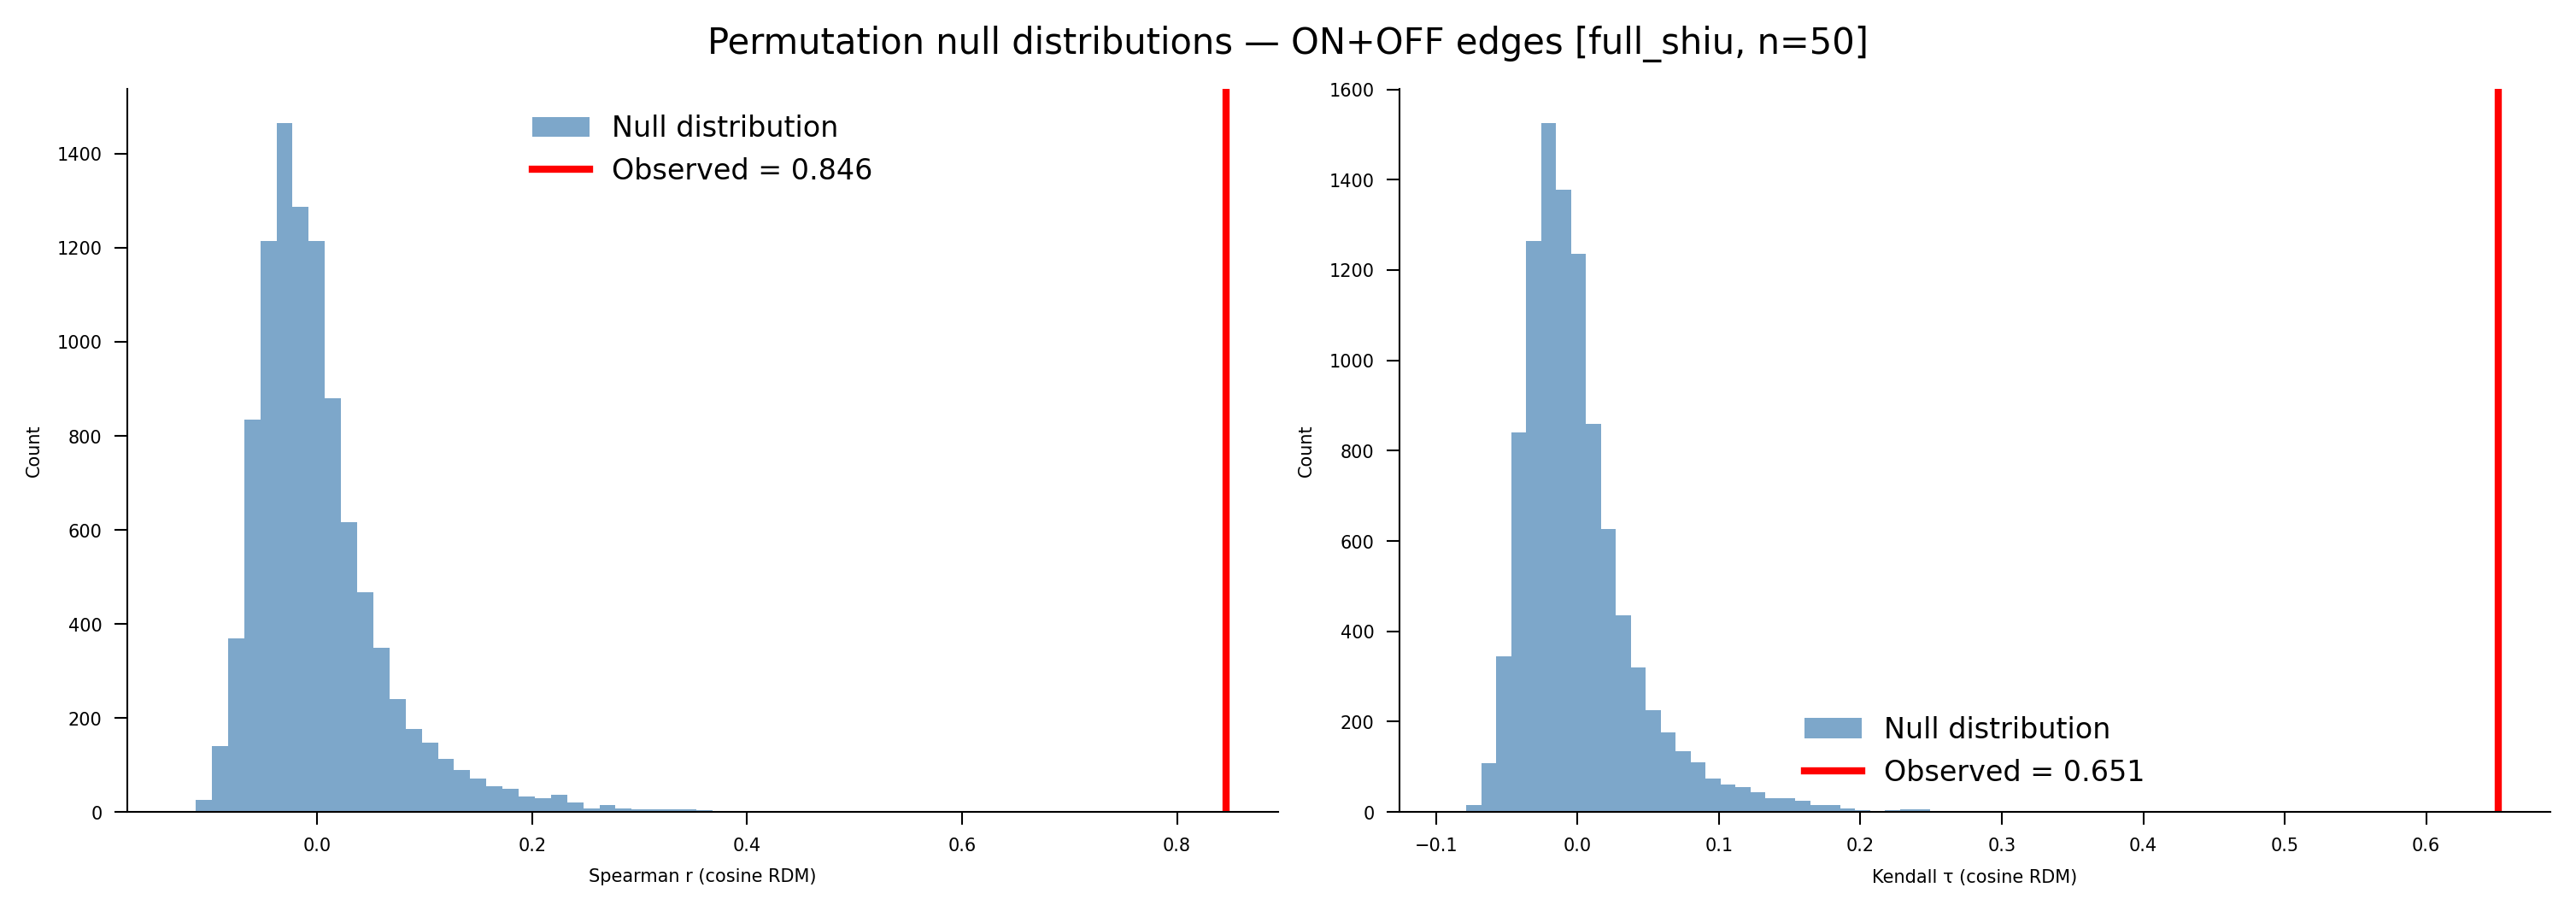


  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.838 ± 0.059

--- GENERATING FIGURE ---
  Saved: moving_edge_on_off_rdms_50models_full_shiu.png


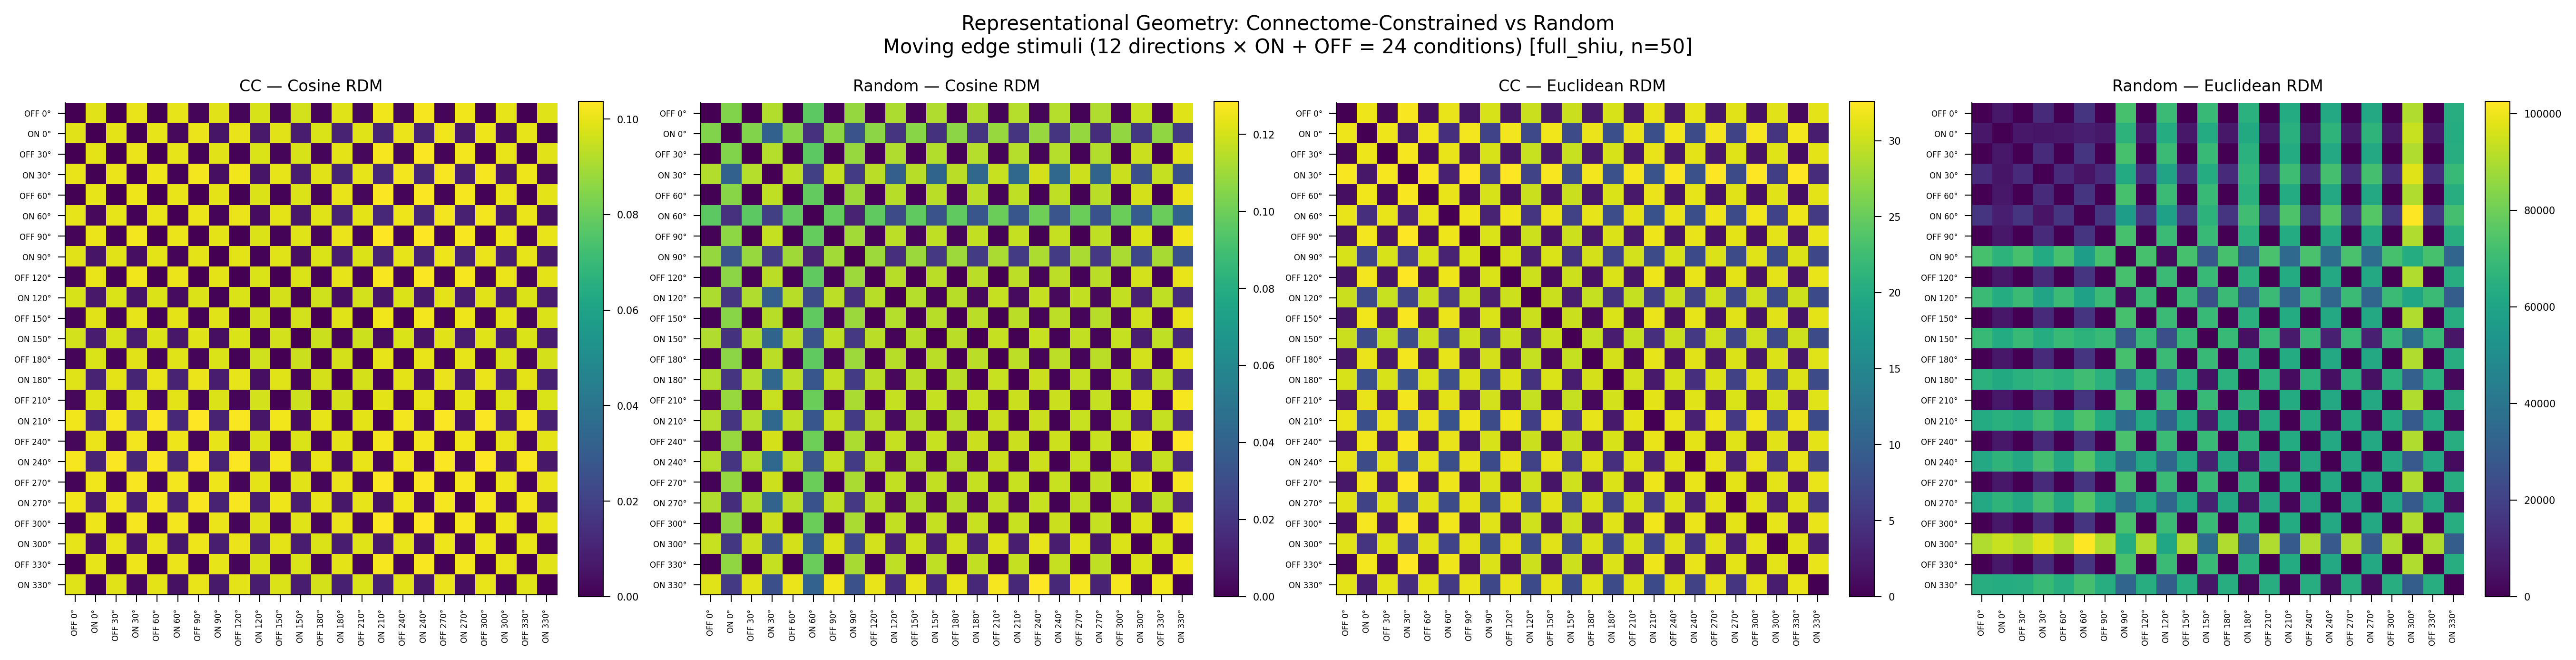


SUMMARY
  N stimuli:              24 (ON + OFF edges, 12 directions each)
  N models:               50
  Randomization strategy: full_shiu
  Population vec dim:     65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = 0.846 | Kendall τ = 0.651  [analytical]
                                     Spearman r = 0.846, p_perm = 0.0000 | Kendall τ = 0.651, p_perm = 0.0000  [permutation]
  Euclidean RDM corr (CC vs random): Spearman r = 0.509 | Kendall τ = 0.342  [analytical]
  Within-CC consistency:             r = 0.838 ± 0.059


{'cc_rdm_cosine': array([[0.        , 0.09920105, 0.00017287, 0.10034801, 0.00065863,
         0.09991537, 0.00128067, 0.09903332, 0.00145632, 0.0972988 ,
         0.00163253, 0.09683304, 0.0018904 , 0.09860764, 0.00223827,
         0.10157373, 0.00219054, 0.10232886, 0.00171847, 0.10155565,
         0.000857  , 0.09979427, 0.00021624, 0.09852644],
        [0.09920105, 0.        , 0.09946348, 0.00057731, 0.10005087,
         0.00247404, 0.10087565, 0.00579521, 0.10035358, 0.00689483,
         0.0989108 , 0.0081323 , 0.09774899, 0.00998286, 0.09853246,
         0.01085062, 0.10057922, 0.00975791, 0.10159371, 0.00702922,
         0.10109797, 0.00355459, 0.09999734, 0.00104214],
        [0.00017287, 0.09946348, 0.        , 0.10050901, 0.00030221,
         0.09995903, 0.00092173, 0.09921773, 0.0011413 , 0.09778481,
         0.00146173, 0.09761437, 0.00187732, 0.09958566, 0.00223125,
         0.10249225, 0.00209099, 0.10292354, 0.00167746, 0.10195153,
         0.00094629, 0.10017885, 0.0004

In [ ]:
results = run_experiment(n_models=50, randomization_strategy="full_shiu")
results

## Save Results to File

In [ ]:
# Save results to .npz file
np.savez("results_exp2_50models_full_shiu.npz",
    cc_rdm_cosine=results["cc_rdm_cosine"],
    rand_rdm_cosine=results["rand_rdm_cosine"],
    cc_rdm_eucl=results["cc_rdm_eucl"],
    rand_rdm_eucl=results["rand_rdm_eucl"],
    cell_types=results["cell_types"],
    stim_labels=results["stim_labels"],
    cc_rdms_cosine=np.array(results["cc_rdms_cosine"]), # added for model-level bootstrap
)
print("Saved results_exp2_50models_full_shiu.npz")

Saved results_exp2_50models_full_shiu.npz


## Within-Polarity Direction Structure, Circular Structure Test, Fisher Z-Transform, and Bootstrap

This cell runs all within-polarity post-hoc analyses in sequence, loading from
the saved n=50 results file. It does not require re-running the experiment.

**Analyses:**

1. **Visualization** — CC and random within-polarity submatrices (OFF-OFF and
   ON-ON) plotted together in a 2×2 grid (CC top row, Random bottom row) with
   row-level shared colormaps — CC row and Random row scaled independently.
   A single shared colormap across all four panels would be dominated by the
   Random ON-ON block (~0.040), compressing the CC gradient into the near-zero
   end. Row-level scaling allows the CC circular gradient to be visible while
   the magnitude difference between rows (CC ~0.012, Random ~0.040) is
   communicated by the different colorbar ranges. Stimulus conditions are
   interleaved by direction (OFF 0°, ON 0°, OFF 30°, ON 30°, ...), so OFF
   conditions occupy even indices (0,2,...,22) and ON conditions occupy odd
   indices (1,3,...,23); `np.ix_` is used to index non-contiguous rows and
   columns simultaneously.

2. **Circular structure test** — the upper triangle of each 12×12 CC submatrix
   is correlated with a circular distance reference matrix, where distance
   between directions i and j equals min(|i−j|, 12−|i−j|), ranging from 0
   (same direction) to 6 (opposite direction). Both Spearman r and a
   permutation p-value are reported (10,000 permutations, rows and columns
   permuted simultaneously to preserve RDM symmetry; Nili et al. 2014).

3. **Fisher z-transform test** — analytical corroboration of the bootstrap
   result. Tests whether Δr = r(ON-ON) − r(OFF-OFF) is significant using a
   closed-form z-test. Approximate because the two correlations share the same
   circular reference; reported as a secondary check alongside the bootstrap
   rather than a primary inference.

4. **Model-level bootstrap** — resamples the 50 CC models with replacement
   (10,000 samples), recomputes the mean RDM for each bootstrap sample,
   extracts the ON-ON and OFF-OFF submatrices, and correlates each with the
   circular reference. The resulting distribution of Δr gives a 95% CI that
   correctly accounts for model-level variability. This is more rigorous than
   the Fisher z-transform and supersedes any prior pair-level bootstrap.

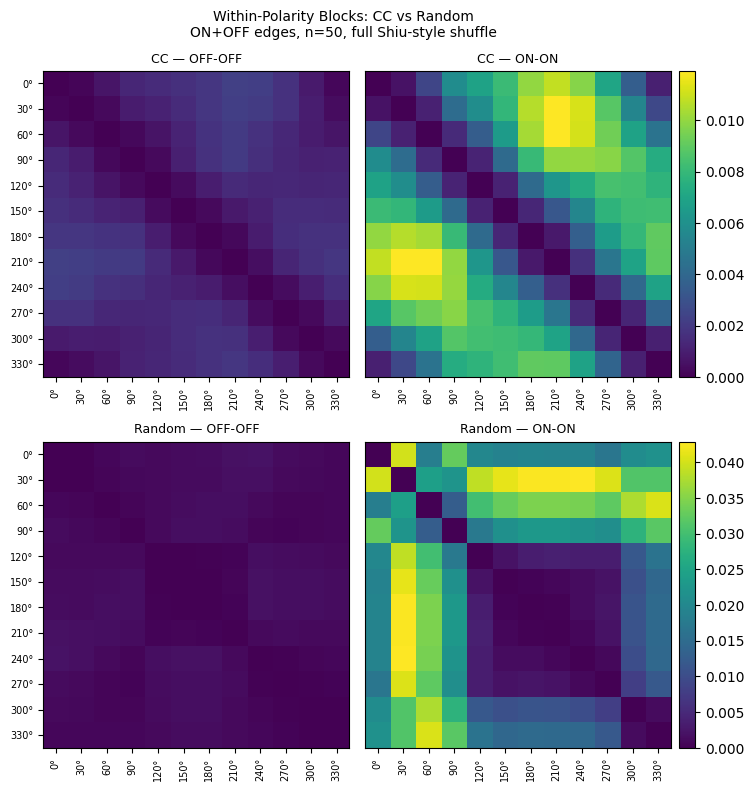

Circular distance reference matrix:
[[0. 1. 2. 3. 4. 5. 6. 5. 4. 3. 2. 1.]
 [1. 0. 1. 2. 3. 4. 5. 6. 5. 4. 3. 2.]
 [2. 1. 0. 1. 2. 3. 4. 5. 6. 5. 4. 3.]
 [3. 2. 1. 0. 1. 2. 3. 4. 5. 6. 5. 4.]
 [4. 3. 2. 1. 0. 1. 2. 3. 4. 5. 6. 5.]
 [5. 4. 3. 2. 1. 0. 1. 2. 3. 4. 5. 6.]
 [6. 5. 4. 3. 2. 1. 0. 1. 2. 3. 4. 5.]
 [5. 6. 5. 4. 3. 2. 1. 0. 1. 2. 3. 4.]
 [4. 5. 6. 5. 4. 3. 2. 1. 0. 1. 2. 3.]
 [3. 4. 5. 6. 5. 4. 3. 2. 1. 0. 1. 2.]
 [2. 3. 4. 5. 6. 5. 4. 3. 2. 1. 0. 1.]
 [1. 2. 3. 4. 5. 6. 5. 4. 3. 2. 1. 0.]]

WITHIN-POLARITY CIRCULAR DIRECTION STRUCTURE TEST
Reference: circular distance matrix (min angular separation)

  ON-ON  block:
    Spearman r = 0.937, p = 0.0000  [analytical]
    p_perm = 0.0000  [10000 permutations]
    0/10000 permutations exceeded observed r

  OFF-OFF block:
    Spearman r = 0.799, p = 0.0000  [analytical]
    p_perm = 0.0000  [10000 permutations]
    0/10000 permutations exceeded observed r

  ON-ON r = 0.937  vs  OFF-OFF r = 0.799
  Difference: 0.138 — ON pathway s

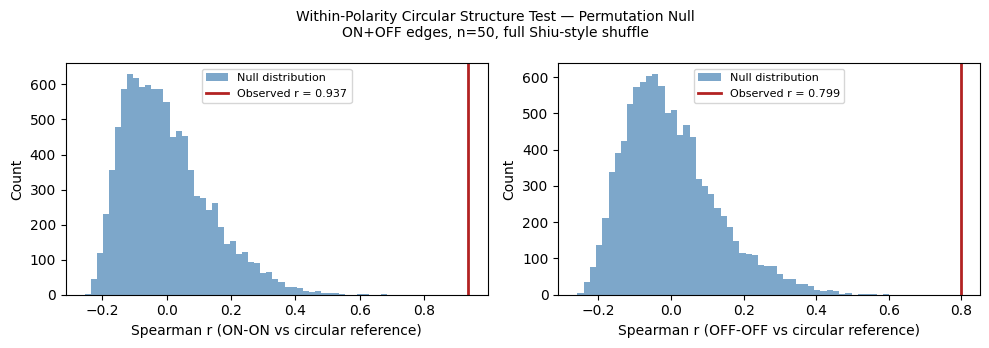


FISHER Z-TRANSFORM TEST: ON/OFF CIRCULAR STRUCTURE ASYMMETRY
  ON-ON  r = 0.937  (Fisher z = 1.711)
  OFF-OFF r = 0.799  (Fisher z = 1.095)
  Difference Δr = 0.138
  z-statistic = 3.454
  p (two-sided) = 0.0006

  Interpretation: the ON-ON block shows significantly stronger circular direction structure than the OFF-OFF block (p < 0.05, two-sided Fisher z-test).
  Caveat: correlations share the same circular reference — approximate test.

BOOTSTRAP TEST: ON/OFF CIRCULAR STRUCTURE ASYMMETRY
  10000 bootstrap samples (model-level resampling, n=50 models)

  Observed Δr = 0.138
  Bootstrap mean Δr = 0.153 ± 0.039
  95% CI: [0.091, 0.236]
  99% CI: [0.078, 0.261]
  p (one-sided, ON <= OFF): 0.0000

  Interpretation: CI excludes zero — ON/OFF asymmetry is significant at 95% level


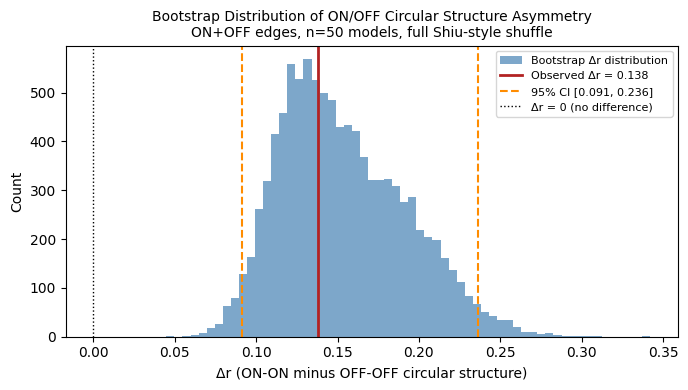

In [18]:
# ── WITHIN-POLARITY DIRECTION STRUCTURE, CIRCULAR STRUCTURE TEST,
#    FISHER Z-TRANSFORM, AND BOOTSTRAP ────────────────────────────────────────
#
# This cell runs all within-polarity analyses in sequence:
#   1. Visualize CC vs Random within-polarity blocks (2×2, row-level colormaps)
#   2. Formally test circular direction structure in each block (permutation test)
#   3. Fisher z-transform test for ON/OFF asymmetry (approximate)
#   4. Bootstrap test for ON/OFF asymmetry (model-level resampling)
#
# Standalone — loads all required data from saved .npz file.
# Requires: results_exp2_50models_full_shiu.npz
# Saves to: within_polarity_blocks_cc_vs_random_50models_full_shiu.png
#           within_polarity_circular_test_50models_full_shiu.png
#           bootstrap_on_off_asymmetry_50models_full_shiu.png

# ── Load results ──────────────────────────────────────────────────────────────
d = np.load("results_exp2_50models_full_shiu.npz", allow_pickle=True)
cc_rdm = d["cc_rdm_cosine"]          # shape (24, 24) — mean CC cosine RDM
cc_rdms_cosine = list(d["cc_rdms_cosine"])  # list of 50 individual 24×24 RDMs
n_cc = len(cc_rdms_cosine)

angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
angle_labels = [f"{a}°" for a in angles]

# Stimulus ordering is interleaved by direction:
# (OFF 0°, ON 0°, OFF 30°, ON 30°, ...) — OFF at even indices, ON at odd indices.
# np.ix_ indexes non-contiguous rows and columns simultaneously.
off_idx = list(range(0, 24, 2))   # OFF: indices 0, 2, 4, ..., 22
on_idx  = list(range(1, 24, 2))   # ON:  indices 1, 3, 5, ..., 23

off_off = cc_rdm[np.ix_(off_idx, off_idx)]  # 12×12 OFF-OFF submatrix
on_on   = cc_rdm[np.ix_(on_idx,  on_idx)]   # 12×12 ON-ON submatrix

# ── 1. Visualize CC vs Random within-polarity blocks (2×2, row-level colormaps) ──
# OFF-OFF and ON-ON submatrices extracted from both the CC and random mean
# cosine RDMs and plotted together in a 2×2 grid (CC top row, Random bottom
# row). Row-level shared colormaps: CC row and Random row scaled independently.
# A single shared colormap across all four panels would be dominated by the
# Random ON-ON block (range ~0–0.040), compressing the CC gradient into the
# near-zero end and making it invisible. Row-level scaling allows the CC
# circular direction gradient to be visible in the top row while preserving
# the ability to compare OFF-OFF vs ON-ON structure within each network type.
# The magnitude difference between CC and random is communicated by the
# different colorbar ranges: a single shared colorbar is shown per row —
# CC row range 0–0.012, Random row range 0–0.040.

rand_rdm     = d["rand_rdm_cosine"]
rand_off_off = rand_rdm[np.ix_(off_idx, off_idx)]
rand_on_on   = rand_rdm[np.ix_(on_idx,  on_idx)]

# Row-level shared colormaps
vmax_cc   = max(off_off.max(),      on_on.max())
vmax_rand = max(rand_off_off.max(), rand_on_on.max())

fig, axes = plt.subplots(2, 2, figsize=(8, 8.5))
fig.subplots_adjust(right=0.91, wspace=0.05, top=0.91)  # reserve space on the right for colorbars

fig.suptitle("Within-Polarity Blocks: CC vs Random\n"
             "ON+OFF edges, n=50, full Shiu-style shuffle", fontsize=10)

panels = [
    (axes[0, 0], off_off,      "CC — OFF-OFF",      vmax_cc),
    (axes[0, 1], on_on,        "CC — ON-ON",         vmax_cc),
    (axes[1, 0], rand_off_off, "Random — OFF-OFF",   vmax_rand),
    (axes[1, 1], rand_on_on,   "Random — ON-ON",     vmax_rand),
]

ims = []
for ax, block, title, vmax_row in panels:
    im = ax.imshow(block, cmap="viridis", vmin=0, vmax=vmax_row)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(12))
    ax.set_xticklabels(angle_labels, fontsize=7, rotation=90)
    ax.set_yticks(range(12))
    ax.set_yticklabels(angle_labels, fontsize=7)
    ims.append(im)

for ax in [axes[0, 1], axes[1, 1]]:
    ax.set_yticks([])

# Add colorbars in dedicated axes outside the plot area
fig.canvas.draw()  # force layout computation

# Get actual positions of the axes
pos00 = axes[0, 0].get_position()  # top-left panel
pos01 = axes[0, 1].get_position()  # top-right panel
pos10 = axes[1, 0].get_position()  # bottom-left panel
pos11 = axes[1, 1].get_position()  # bottom-right panel

# Place colorbars aligned to the right edge of column 1 and vertically matching each row
cax1 = fig.add_axes([pos01.x1 + 0.01, pos01.y0, 0.02, pos01.height])
cax2 = fig.add_axes([pos11.x1 + 0.01, pos11.y0, 0.02, pos11.height])
fig.colorbar(ims[0], cax=cax1)
fig.colorbar(ims[2], cax=cax2)

plt.savefig("within_polarity_blocks_cc_vs_random_50models_full_shiu.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Circular distance reference matrix ─────────────────────────────────────
# For 12 directions at 30° increments, circular distance between directions
# i and j is min(|i-j|, 12-|i-j|), ranging from 0 (same) to 6 (opposite).
# This is the expected ordinal dissimilarity under pure direction tuning.
n_dirs = 12
circ_ref = np.zeros((n_dirs, n_dirs))
for i in range(n_dirs):
    for j in range(n_dirs):
        circ_ref[i, j] = min(abs(i - j), n_dirs - abs(i - j))

print("Circular distance reference matrix:")
print(circ_ref)

def test_circular_structure(submatrix, label, circ_ref, n_permutations=10000,
                            seed=SEED):
    """
    Test whether a 12×12 within-polarity submatrix has circular direction
    structure by correlating its upper triangle with the circular distance
    reference. Reports Spearman r, analytical p, and permutation p-value.
    Permutation test: rows and columns of submatrix permuted simultaneously
    to preserve RDM symmetry (Nili et al. 2014).
    """
    n = submatrix.shape[0]
    idx = np.triu_indices(n, k=1)
    obs_r, obs_p = spearmanr(submatrix[idx], circ_ref[idx])

    rng = np.random.default_rng(seed)
    null_r = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        submatrix_p = submatrix[np.ix_(perm, perm)]
        null_r[i], _ = spearmanr(submatrix_p[idx], circ_ref[idx])
    p_perm = np.mean(null_r >= obs_r)

    print(f"\n  {label}:")
    print(f"    Spearman r = {obs_r:.3f}, p = {obs_p:.4f}  [analytical]")
    print(f"    p_perm = {p_perm:.4f}  [{n_permutations} permutations]")
    print(f"    {int(p_perm * n_permutations)}/{n_permutations} permutations "
          f"exceeded observed r")
    return obs_r, obs_p, p_perm, null_r

print("\n" + "="*60)
print("WITHIN-POLARITY CIRCULAR DIRECTION STRUCTURE TEST")
print("Reference: circular distance matrix (min angular separation)")
print("="*60)

r_on,  p_on,  p_perm_on,  null_on  = test_circular_structure(
    on_on,  "ON-ON  block", circ_ref)
r_off, p_off, p_perm_off, null_off = test_circular_structure(
    off_off, "OFF-OFF block", circ_ref)

print(f"\n  ON-ON r = {r_on:.3f}  vs  OFF-OFF r = {r_off:.3f}")
print(f"  Difference: {r_on - r_off:.3f} — ON pathway shows "
      f"{'stronger' if r_on > r_off else 'weaker'} directional geometry")

# Plot permutation null distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle("Within-Polarity Circular Structure Test — Permutation Null\n"
             "ON+OFF edges, n=50, full Shiu-style shuffle", fontsize=10)

for ax, null, obs, label in zip(
    axes,
    [null_on,  null_off],
    [r_on,     r_off],
    ["ON-ON vs circular reference", "OFF-OFF vs circular reference"]
):
    ax.hist(null, bins=50, color="steelblue", alpha=0.7, label="Null distribution")
    ax.axvline(obs, color="firebrick", linewidth=2, label=f"Observed r = {obs:.3f}")
    ax.set_xlabel(f"Spearman r ({label})")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("within_polarity_circular_test_50models_full_shiu.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Fisher z-transform test (approximate) ──────────────────────────────────
# Analytical corroboration of the bootstrap result. Tests whether Δr is
# statistically significant using a closed-form z-test. Approximate because
# the two correlations share the same circular reference and are not fully
# independent; reported as a secondary check alongside the bootstrap.
#
# n_pairs = upper triangle of 12×12 matrix = 12*(12-1)/2 = 66

n_pairs = 66

def fisher_z(r):
    """Fisher z-transform of a correlation coefficient."""
    return 0.5 * np.log((1 + r) / (1 - r))

def fisher_z_test(r1, r2, n1, n2):
    """Two-sample Fisher z-transform test. Returns z-statistic and two-sided p-value."""
    z1 = fisher_z(r1)
    z2 = fisher_z(r2)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_two_sided = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_two_sided

z_stat, p_val = fisher_z_test(r_on, r_off, n_pairs, n_pairs)

print("\n" + "="*60)
print("FISHER Z-TRANSFORM TEST: ON/OFF CIRCULAR STRUCTURE ASYMMETRY")
print("="*60)
print(f"  ON-ON  r = {r_on:.3f}  (Fisher z = {fisher_z(r_on):.3f})")
print(f"  OFF-OFF r = {r_off:.3f}  (Fisher z = {fisher_z(r_off):.3f})")
print(f"  Difference Δr = {r_on - r_off:.3f}")
print(f"  z-statistic = {z_stat:.3f}")
print(f"  p (two-sided) = {p_val:.4f}")
print(f"\n  Interpretation: the ON-ON block shows "
      f"{'significantly' if p_val < 0.05 else 'non-significantly'} "
      f"stronger circular direction structure than the OFF-OFF block "
      f"(p {'< 0.05' if p_val < 0.05 else '>= 0.05'}, two-sided Fisher z-test).")
print(f"  Caveat: correlations share the same circular reference — approximate test.")

# ── 4. Bootstrap test (model-level resampling) ────────────────────────────────
# Resamples the 50 CC models with replacement, recomputes the mean RDM for
# each bootstrap sample, extracts the ON-ON and OFF-OFF submatrices, and
# correlates each with the circular reference. The distribution of Δr across
# 10,000 bootstrap samples gives a 95% CI on the ON/OFF asymmetry that
# correctly accounts for model-level variability. This is the primary
# inference test for the asymmetry; the Fisher z-transform above serves
# as an analytical cross-check.

N_BOOTSTRAP = 10000
rng_boot = np.random.default_rng(SEED)
delta_r_boot = np.zeros(N_BOOTSTRAP)
idx_upper = np.triu_indices(12, k=1)

print("\n" + "="*60)
print("BOOTSTRAP TEST: ON/OFF CIRCULAR STRUCTURE ASYMMETRY")
print(f"  {N_BOOTSTRAP} bootstrap samples (model-level resampling, n={n_cc} models)")
print("="*60)

for b in range(N_BOOTSTRAP):
    # Resample model indices with replacement
    boot_idx = rng_boot.integers(0, n_cc, size=n_cc)
    # Compute mean RDM across bootstrap sample
    boot_mean = np.mean([cc_rdms_cosine[i] for i in boot_idx], axis=0)
    # Extract within-polarity submatrices
    boot_on_on   = boot_mean[np.ix_(on_idx,  on_idx)]
    boot_off_off = boot_mean[np.ix_(off_idx, off_idx)]
    # Correlate each with circular reference
    r_on_b,  _ = spearmanr(boot_on_on[idx_upper],  circ_ref[idx_upper])
    r_off_b, _ = spearmanr(boot_off_off[idx_upper], circ_ref[idx_upper])
    delta_r_boot[b] = r_on_b - r_off_b

ci_95 = np.percentile(delta_r_boot, [2.5, 97.5])
ci_99 = np.percentile(delta_r_boot, [0.5, 99.5])
p_boot = np.mean(delta_r_boot <= 0)  # one-sided: proportion where ON <= OFF

print(f"\n  Observed Δr = {r_on - r_off:.3f}")
print(f"  Bootstrap mean Δr = {delta_r_boot.mean():.3f} ± {delta_r_boot.std():.3f}")
print(f"  95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}]")
print(f"  99% CI: [{ci_99[0]:.3f}, {ci_99[1]:.3f}]")
print(f"  p (one-sided, ON <= OFF): {p_boot:.4f}")
print(f"\n  Interpretation: "
      f"{'CI excludes zero — ON/OFF asymmetry is significant at 95% level' if ci_95[0] > 0 else 'CI includes zero — asymmetry not significant at 95% level'}")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(delta_r_boot, bins=60, color="steelblue", alpha=0.7,
        label="Bootstrap Δr distribution")
ax.axvline(r_on - r_off, color="firebrick", linewidth=2,
           label=f"Observed Δr = {r_on - r_off:.3f}")
ax.axvline(ci_95[0], color="darkorange", linewidth=1.5, linestyle="--",
           label=f"95% CI [{ci_95[0]:.3f}, {ci_95[1]:.3f}]")
ax.axvline(ci_95[1], color="darkorange", linewidth=1.5, linestyle="--")
ax.axvline(0, color="black", linewidth=1, linestyle=":",
           label="Δr = 0 (no difference)")
ax.set_xlabel("Δr (ON-ON minus OFF-OFF circular structure)")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of ON/OFF Circular Structure Asymmetry\n"
             "ON+OFF edges, n=50 models, full Shiu-style shuffle", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("bootstrap_on_off_asymmetry_50models_full_shiu.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 24×24 dissimilarity
matrix with clear polarity-dependent block organization. Within each polarity
block (ON-ON and OFF-OFF), the same circular direction gradient observed in
Experiment 1 is preserved: adjacent directions are most similar and opposite
directions most dissimilar — though this structure is not visible in the full
24×24 figure due to colormap compression by the dominant cross-polarity signal
(see Within-Polarity Direction Structure below). Across polarity (ON vs OFF
pairs), dissimilarities are large and nearly uniform at 0.099–0.103 — the
network represents ON and OFF edges as geometrically distinct populations
regardless of direction. This block structure is consistent with the known
segregation of the fly visual system into ON (T4) and OFF (T5) pathways.
Within-ensemble consistency is high at both n=10 (r = 0.850 ± 0.057) and n=50
(r = 0.838 ± 0.059), notably higher and tighter than the n=50 ON-only result
(r = 0.721 ± 0.150), consistent with polarity being a stronger organizer of
representational geometry than direction alone.

### Within-Polarity Direction Structure
To visualize the within-polarity circular gradient obscured by the dominant
cross-polarity contrast in the full 24×24 RDM, the OFF-OFF and ON-ON
submatrices were extracted from both the CC and random mean cosine RDMs
(OFF conditions at interleaved even indices 0,2,...,22; ON conditions at odd
indices 1,3,...,23) and plotted together in a 2×2 grid (CC top row, Random
bottom row) with row-level shared colormaps — CC row and Random row scaled
independently. This allows the CC circular direction gradient to be visible
in the top row while preserving the ability to compare OFF-OFF vs ON-ON
structure within each network type. The magnitude difference between CC and
random is communicated by the different colorbar ranges: CC row peaks at
~0.012, Random row at ~0.040.

The CC ON-ON block (top right) shows a clear circular direction gradient —
adjacent directions most similar, opposite directions most dissimilar —
consistent with the Experiment 1 result. The CC OFF-OFF block (top left)
shows the same ordinal structure at a compressed range, appearing darker
overall. The random ON-ON block (bottom right) shows a structured but
non-circular pattern with large values unrelated to angular distance. The
random OFF-OFF block (bottom left) is nearly uniform, showing no directional
structure. This 2×2 comparison confirms that the CC representational geometry
encodes direction within each polarity channel in a way that random networks
do not.

The within-polarity direction structure was not visible in the full 24×24
figure because the cross-polarity dissimilarity (0.099–0.103) dominates the
colormap scale, compressing the within-polarity range (0.001–0.012) into the
near-zero end.

### Within-Polarity Circular Structure Test

To formally test whether each polarity block contains a circular direction
gradient, the upper triangle of each 12×12 submatrix was correlated with a
circular distance reference — the expected ordinal dissimilarity under pure
direction tuning, where distance between directions i and j equals
min(|i−j|, 12−|i−j|), ranging from 0 (same direction) to 6 (opposite
direction, 180° apart).

Both blocks show highly significant circular structure. ON-ON: **Spearman
r = 0.937, p < 0.0001** (analytical); **p_perm < 0.0001** (10,000
permutations) — zero of 10,000 permutations exceeded the observed correlation.
OFF-OFF: **Spearman r = 0.799, p < 0.0001** (analytical); **p_perm < 0.0001**
(10,000 permutations) — zero of 10,000 permutations exceeded the observed
correlation. Both observed values fall far outside the null distribution,
confirming that the circular direction gradient is a genuine property of the
CC representational geometry in both polarity channels, not a visual artifact
of the submatrix extraction.

The ON-ON block shows substantially stronger circular structure than the
OFF-OFF block (r = 0.937 vs r = 0.799, Δr = 0.138). A Fisher z-transform
test confirms this difference is statistically significant (z = 3.454,
p = 0.0006, two-sided). A model-level bootstrap (10,000 samples, 50 CC
models resampled with replacement) corroborates this: bootstrap mean
Δr = 0.153 ± 0.039, 95% CI [0.091, 0.236], p < 0.0001 (one-sided). The
95% CI excludes zero, confirming that the ON pathway encodes direction with
significantly stronger geometric separation than the OFF pathway. The
Fisher z-transform is approximate — the two correlations share the same
circular reference — but the model-level bootstrap provides a more rigorous
inference that correctly accounts for model-level variability.

### Dynamic Instability
Dynamic instability is robust across all randomization strategies tested,
motivating the development of a stability-constrained baseline. Under the full
Shiu-style shuffle at n=10 (matched-instability approach), 5 of 10 random
models were unstable (1,512 non-finite values each, corresponding to 63 of 65
cell types across all 24 stimuli) — identical model indices as Experiment 1
(models 2, 3, 4, 8, 9), confirming that the instability pattern is fully
reproducible under seed=42 regardless of stimulus count. Under the synapse-only
shuffle at n=50, 35 of 50 random models (70%) were unstable — comparable to
the Experiment 1 synapse-only rate (34/50, 68%). Zero of 50 CC models showed
any instability under any condition. The biological connectome, as optimized by
task training, reliably occupies a dynamically stable region of parameter space
that random weight configurations consistently leave.

### Stability-Constrained Random Baseline

**n=10:** Under stability-constrained full Shiu-style shuffling (MAX_ATTEMPTS=100),
all 10 models were accepted. Acceptance required on average 11.1 ± 11.5 attempts
per model (range: 1–33), with only 3/10 models accepted on the first attempt —
consistent with Experiment 1 (mean 11.1 ± 9.9, 1/10 first-try), confirming that
the stable volume of full Shiu weight space is similarly small across both
stimulus sets.

**n=50:** All 50 models were accepted under the same procedure. Acceptance
required on average 7.9 ± 8.5 attempts per model (range: 1–42), with 6/50
models accepted on the first attempt. The worst-case model required 42 attempts,
well within the MAX_ATTEMPTS=100 ceiling. The acceptance rate profile is nearly
identical to Experiment 1 n=50 (mean 7.9 ± 8.1, 5/50 first-try), confirming
that stability constraints on the full Shiu weight space are stimulus-set
independent.

The accepted random baseline produces a cosine RDM with an alternating
checkerboard-like organization driven by polarity: OFF-condition pairs and
ON-condition pairs each form clusters of moderate dissimilarity, while
cross-polarity pairs are uniformly large. This polarity sensitivity is
accidental — it reflects the stable random weight configuration's response
characteristics rather than biologically organized ON/OFF pathway segregation —
and is qualitatively different from the tight, direction-resolved circular
gradient within each polarity block in the CC RDM.

### CC vs Random RDM Correlation

**Stability-constrained baseline, n=10 (comparison result):**
Cosine RDM correlation: **Spearman r = 0.783, p < 0.0001 | Kendall τ = 0.562,
p < 0.0001** (analytical); **p_perm < 0.0001 for both measures**
(stimulus-label randomization test, 10,000 permutations, Nili et al. 2014) —
zero of 10,000 permutations exceeded the observed correlation. The result is
highly significant by all three independent inference methods.

Euclidean RDM correlation: **Spearman r = 0.522, p < 0.0001 | Kendall τ =
0.349, p < 0.0001** (analytical); **p_perm < 0.0001 for both measures**
(permutation). Significant but interpreted with caution: the random Euclidean
RDM contains values on the order of 1e4–1e5 (up to ~5e5 in some cells),
indicating near-overflow activations on stimuli not covered by the
single-stimulus stability check. Cosine RDM correlation remains the primary
reported metric.

**Stability-constrained baseline, n=50 (canonical result):**
Cosine RDM correlation: **Spearman r = 0.846, p < 0.0001 | Kendall τ = 0.651,
p < 0.0001** (analytical); **p_perm < 0.0001 for both measures** — zero of
10,000 permutations exceeded the observed correlation. The result is highly
significant by all three independent inference methods. Notably, the n=50
result (r = 0.846) is higher than the n=10 result (r = 0.783), the opposite
of the Experiment 1 pattern (r = 0.686 at n=50 vs r = 0.749 at n=10). This
likely reflects the averaging effect of 50 independently accepted random
configurations: the mean random cosine RDM at n=50 is a smoother estimate
of the stable random weight distribution, which happens to be more
discriminable from the CC geometry than the single-configuration n=10 baseline.

Euclidean RDM correlation: **Spearman r = 0.509, p < 0.0001 | Kendall τ =
0.342, p < 0.0001** (analytical); **p_perm = 0.0001 | p_perm = 0.0002**
(permutation). Significant but interpreted with caution for the same
scale distortion reasons as n=10.

**Matched-instability baseline (historical comparison):**
Under the previous matched-instability approach (full Shiu-style shuffle, n=10,
5/10 stable random models): cosine RDM correlation **Spearman r = 0.862,
p < 0.0001 | Kendall τ = 0.660, p < 0.0001** (analytical); **p_perm < 0.0001**
(permutation). The stability-constrained n=10 result (r = 0.783) is modestly
lower than the matched-instability result (r = 0.862), a larger gap than
observed in Experiment 1 (0.749 vs 0.757), suggesting that clamped instability
may modestly inflate the matched-instability result in the 24-condition case.
Nonetheless, both results are highly significant and the primary conclusion
holds under both baseline constructions.

Cosine RDM correlation is NaN under the synapse-only shuffle at n=50 (35/50
unstable). Euclidean RDM correlation under synapse-only shuffle at n=50:
**Spearman r = 0.313, p < 0.0001** — nominally significant but not
interpretable due to extreme magnitudes from unstable models.

### Within-Ensemble Consistency
At n=10, mean pairwise RDM correlation: **r = 0.850 ± 0.057** (range:
0.706–0.954). At n=50, mean pairwise RDM correlation: **r = 0.838 ± 0.059**.
Both are notably higher and tighter than the n=50 ON-only result (r = 0.721 ±
0.150), suggesting that the ON+OFF stimulus set produces a more consistent
representational geometry across the full ensemble. The n=10 ON+OFF result
(r = 0.850) also slightly exceeds the n=10 ON-only result (r = 0.838 ± 0.078),
consistent with polarity being a stronger organizer of representational geometry
than direction alone.

## Discussion
- Stability-constrained baseline now covers both n=10 and n=50 with all models
  accepted; the fidelity result holds at both scales (r = 0.783 at n=10,
  r = 0.846 at n=50), with both p_perm < 0.0001
- The n=50 result exceeds n=10 (0.846 vs 0.783), the reverse of Experiment 1
  (0.686 vs 0.749); the most likely explanation is that averaging 50 stable
  random configurations produces a smoother mean random RDM that is more
  discriminable from the CC geometry
- Stability-constrained and matched-instability baselines both yield highly
  significant cosine RDM correlations (r = 0.783 vs 0.862 at n=10); the larger
  gap than Experiment 1 (0.749 vs 0.757) suggests clamped instability may
  modestly inflate the matched-instability result in the 24-condition case
- Dynamic instability pattern is fully reproducible across both experiments
  under seed=42: identical model indices fail under the same randomization
  strategy, confirming instability is determined by weight configuration, not
  stimulus set
- Acceptance rate profile at n=50 (mean 7.9 ± 8.5, 6/50 first-try) is nearly
  identical to Experiment 1 n=50 (7.9 ± 8.1, 5/50 first-try), confirming that
  stability constraints on full Shiu weight space are stimulus-set independent
- The random Euclidean RDM retains very large values despite stability-
  constrained sampling, confirming that single-stimulus stability checking is
  insufficient to guarantee well-behaved responses across all 24 stimuli; cosine
  distance is the appropriate primary metric
- Within-CC consistency at n=50 (r = 0.838 ± 0.059) is substantially higher
  and tighter than Experiment 1 n=50 (r = 0.721 ± 0.150), supporting polarity
  as a stronger organizer of representational geometry than direction alone
- Within-CC consistency should be reported separately per cluster if UMAP
  reveals substructure in the ensemble geometry (planned)
- The OFF-OFF within-polarity block shows significantly weaker circular
  direction structure than the ON-ON block (r = 0.799 vs r = 0.937 vs
  circular reference, both p_perm < 0.0001, Δr = 0.138); the asymmetry is
  confirmed by both Fisher z-transform (z = 3.454, p = 0.0006) and
  model-level bootstrap (95% CI [0.091, 0.236], p < 0.0001), consistent
  with known T4/T5 differences in direction selectivity strength

## Download Figures

In [ ]:
# Download figure to local machine
files.download("moving_edge_on_off_rdms_50models_full_shiu.png")
files.download("moving_edge_on_off_permtest_50models_full_shiu.png")
files.download("within_polarity_blocks_cc_vs_random_50models_full_shiu.png")
files.download("within_polarity_circular_test_50models_full_shiu.png")
files.download("bootstrap_on_off_asymmetry_50models_full_shiu.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download Results File

In [ ]:
# Download results file to local machine
files.download("results_exp2_50models_full_shiu.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>